## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('../')
import STACAME 
import os
os.environ['R_HOME'] = "/data/zhanglab/zhangbiao/anaconda3/envs/env_stasage/lib/R"
os.environ['R_USER'] = "/data/zhanglab/zhangbiao/anaconda3/envs/env_stasage/lib/python3.11/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg
from scipy.sparse import csr_matrix
import pandas as pd
import torch
from STACAME.analysis import merge_embedding
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score
import seaborn as sns

import colorcet as cc

In [3]:
# data_path =  '../Experiment_3d_cerebellar/3d_visualization/stitch3d_spateo/Mouse/'
# section_name_list = ['adata_st']
# for section_name in section_name_list:
#     save_section_name = section_name
#     section_name = section_name + '.h5ad'
#     adata = sc.read_h5ad(data_path + section_name)
#     adata.obsm['spatial'] = adata.obsm['3D_coor']
#     sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
#     adata = adata[:, adata.var['highly_variable']]
#     adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

In [4]:
# data_path =  '../Experiment_3d_cerebellar/3d_visualization/stitch3d_spateo/Marmoset/'
# section_name_list = ['adata_st']
# for section_name in section_name_list:
#     save_section_name = section_name
#     section_name = section_name + '.h5ad'
#     adata = sc.read_h5ad(data_path + section_name)
#     adata.obsm['spatial'] = adata.obsm['3D_coor']
#     sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
#     adata = adata[:, adata.var['highly_variable']]
#     adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

In [5]:

# data_path =  '../Experiment_3d_cerebellar/3d_visualization/stitch3d_spateo/Macaque/'
# section_name_list = ['adata_st']
# for section_name in section_name_list:
#     save_section_name = section_name
#     section_name = section_name + '.h5ad'
#     adata = sc.read_h5ad(data_path + section_name)
#     adata.obsm['spatial'] = adata.obsm['3D_coor']
#     sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
#     adata = adata[:, adata.var['highly_variable']]
#     adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

In [6]:
def clustering_umap_spatial(adata_dict, key_umap='STACAME'):
    k = 0
    for species_id, adata in adata_dict.items():
        if k == 0:
            embedding_X = adata.obsm[key_umap]
            embedding_spatial = adata.obsm['spatial']
            embedding_obs_name = list(adata.obs_names)
            embedding_slice_name = list(adata.obs['slice_name']) 
            embedding_batch_name = list(adata.obs['batch_name'])
            embedding_species_id = list(adata.obs['species_id'])
            embedding_annotation = list(adata.obs['annotation'])
        else:
            embedding_X = np.concatenate((embedding_X, adata.obsm[key_umap]), axis=0)
            embedding_spatial = np.concatenate((embedding_spatial, adata.obsm['spatial']), axis=0)
            embedding_obs_name = embedding_obs_name + list(adata.obs_names)
            embedding_slice_name = embedding_slice_name + list(adata.obs['slice_name']) 
            embedding_batch_name = embedding_batch_name + list(adata.obs['batch_name'])
            embedding_species_id = embedding_species_id + list(adata.obs['species_id'])
            embedding_annotation = embedding_annotation + list(adata.obs['annotation'])
        k += 1

        #adata_dict[species_id] = adata

    adata_embedding = ad.AnnData(X = embedding_X, obs=embedding_obs_name)
    adata_embedding.obsm['spatial'] = embedding_spatial
    adata_embedding.obs['slice_name'] = embedding_slice_name
    adata_embedding.obs['batch_name'] = embedding_batch_name
    adata_embedding.obs['species_id'] = embedding_species_id
    adata_embedding.obs['annotation'] = embedding_annotation
    
    sc.pp.neighbors(adata_embedding,  n_neighbors=20, use_rep='X', metric='cosine',  random_state=666)
    sc.tl.louvain(adata_embedding, random_state=666, key_added="louvain", resolution=0.5)
    #sc.tl.leiden(adata_embedding, random_state=666, key_added="leiden", resolution=0.1)
    print(adata_embedding.X.shape)
    sc.tl.umap(adata_embedding, min_dist=1, random_state=666)
    species_ids = list(adata_dict.keys())
    
    species_color = ['#4778FA', '#8A4AA2', '#ED7A43'] #['#ff7f0e', '#1f77b4'] #'#8A1C62',
    species_color_dict = dict(zip(species_ids, species_color))
    adata_embedding.uns['species_colors'] = [species_color_dict[x] for x in adata_embedding.obs.species_id]
    plt.rcParams['font.sans-serif'] = "Arial"
    plt.rcParams["figure.figsize"] = (4, 4)
    plt.rcParams['font.size'] = 10
    # mclust clustering
    for i in range(len(species_ids)):
        species_id = species_ids[i]
        adata_mh = adata_embedding[adata_embedding.obs['species_id'].isin([species_id])]
       
        num_clusters = len(adata_mh.obs['annotation'].unique())
        
        adata_mh.obsm[key_umap] = adata_mh.X
        STACAME.mclust_R(adata_mh, num_cluster=num_clusters, used_obsm=key_umap)
        
        print('mclust, ARI = %01.3f' % ari_score(adata_mh.obs['annotation'], adata_mh.obs['mclust']))
        
        sc.pl.umap(adata_mh, color=['annotation', 'mclust'], ncols=2, wspace=0.5, show=True)
        color_list = sns.color_palette(cc.glasbey, n_colors=len(adata_mh.obs['annotation'].unique())).as_hex()
        print(color_list)
       
        region_list = ['granular layer', 'molecular layer', 'purkinje layer', 'white matter']
    
        palette = {k:v for k,v in zip(region_list, color_list)}
        sc.pl.umap(adata_mh, color='annotation',  wspace=0.5, show=False, palette = palette, size=10, legend_loc='on data') #legend_fontweight='normal',
    plt.show()
    return adata_dict, adata_embedding


def combine_adata(adata_dict, key_umap='STACAME'):
    k = 0
    for species_id, adata in adata_dict.items():
        if k == 0:
            embedding_X = adata.obsm[key_umap]
            embedding_spatial = adata.obsm['spatial']
            embedding_obs_name = list(adata.obs_names)
            embedding_slice_name = list(adata.obs['slice_name']) 
            embedding_batch_name = list(adata.obs['batch_name'])
            embedding_species_id = list(adata.obs['species_id'])
            embedding_annotation = list(adata.obs['annotation'])
        else:
            embedding_X = np.concatenate((embedding_X, adata.obsm[key_umap]), axis=0)
            embedding_spatial = np.concatenate((embedding_spatial, adata.obsm['spatial']), axis=0)
            embedding_obs_name = embedding_obs_name + list(adata.obs_names)
            embedding_slice_name = embedding_slice_name + list(adata.obs['slice_name']) 
            embedding_batch_name = embedding_batch_name + list(adata.obs['batch_name'])
            embedding_species_id = embedding_species_id + list(adata.obs['species_id'])
            embedding_annotation = embedding_annotation + list(adata.obs['annotation'])
        k += 1

        #adata_dict[species_id] = adata

    adata_embedding = ad.AnnData(X = embedding_X, obs=embedding_obs_name)
    adata_embedding.obsm['spatial'] = embedding_spatial
    adata_embedding.obs['slice_name'] = embedding_slice_name
    adata_embedding.obs['batch_name'] = embedding_batch_name
    adata_embedding.obs['species_id'] = embedding_species_id
    adata_embedding.obs['annotation'] = embedding_annotation
    return adata_dict, adata_embedding

In [7]:
import pickle

root_data_path = '../Data/9_Cerebellar_3d/'
Gene_map_raw_path = './Data/9_Cerebellar_3d/Mouse_Marmoset_Macaque.tsv'
rad_cutoff_dict = {'Mouse':1.05, 'Marmoset':1.05, 'Macaque':1.05}
species_section_ids = {'Mouse':['adata_st_load_3sections'],
                       'Marmoset':['adata_st_load_3sections'],
                       'Macaque':['adata_st_load_3sections']}
species_ortholog_column_dict = {'Mouse':'Gene name', 
                                'Marmoset':'White-tufted-ear marmoset gene name', 
                               'Macaque':'Macaque gene name'}
species_ortholog_type_dict = {'Marmoset':'White-tufted-ear marmoset homology type', 
                               'Macaque':'Macaque homology type'}
species_id_map = {'Mouse':0, 'Marmoset':1, 'Macaque':2}


output_path = root_data_path + 'output_STACAME/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

load_processed = True

if load_processed:
    with open(output_path + 'adata_dict.pkl', 'rb') as fp:
        adata_dict = pickle.load(fp)
    with open(output_path + 'triplet_ind_species_dict.pkl', 'rb') as fp:
        triplet_ind_species_dict = pickle.load(fp)
    edge_ndarray_species = np.load(output_path + 'edge_ndarray_species.npy') 
    with open(output_path + 'triplet_ind_sections_dict.pkl', 'rb') as fp:
        triplet_ind_sections_dict = pickle.load(fp)
    edge_ndarray_sections = np.load(output_path + 'edge_ndarray_sections.npy') 
else:
    STACAME_processer = STACAME.STACAME_processer_subgraph(root_data_path=root_data_path,
                 Gene_map_raw_path=Gene_map_raw_path, 
                 species_section_ids = species_section_ids, 
                 species_ortholog_column_dict = species_ortholog_column_dict, 
                 species_ortholog_type_dict = species_ortholog_type_dict, 
                 species_id_map = species_id_map, 
                 rad_cutoff_dict = rad_cutoff_dict,
                 gene_cap_upper_dict = {'Mouse':'capitalize', 'Marmoset':'upper', 'Macaque':'upper'},
                 Down_sampling_adata = None, 
                 n_top_genes = 500, 
                 homo_n_top_genes = 1500, 
                 cross_species_neibors_K_mnn = 30, 
                 cross_species_neibors_K_knn = 1, 
                 cross_sections_neibors_K_mnn = 1,
                 Smooth_spatial_neighbors = {'Mouse':0, 'Marmoset':0, 'Macaque':0}, 
                 total_normalize = {'Mouse':1e4, 'Marmoset':1e4, 'Macaque':1e4},
                 knn_triplets = False, 
                 knn_triplets_ratio=1, 
                 if_hvg_before_mnn = False, 
                 if_integrate_within_species = True, 
                 if_combat_mnn = False, 
                 if_pca_before_mnn = True, pca_dim_before_mnn = 40)
    adata_dict, triplet_ind_species_dict, edge_ndarray_species, triplet_ind_sections_dict, edge_ndarray_sections = STACAME_processer.load_process_adata_3d() #
   
    with open(output_path + 'adata_dict.pkl', 'wb') as fp:
        pickle.dump(adata_dict, fp)
    with open(output_path + 'triplet_ind_species_dict.pkl', 'wb') as fp:
        pickle.dump(triplet_ind_species_dict, fp)
    with open(output_path + 'triplet_ind_sections_dict.pkl', 'wb') as fp:
        pickle.dump(triplet_ind_sections_dict, fp)
    np.save(output_path + 'edge_ndarray_species.npy', edge_ndarray_species)
    np.save(output_path + 'edge_ndarray_sections.npy', edge_ndarray_sections)

## Running STACAME

Mouse AnnData object with n_obs × n_vars = 1810619 × 5000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation', 'batch_name', 'slice_name', 'slice', 'species_id', 'region_name', 'array_row', 'array_col', 'batch'
    var: 'geneID', 'features', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'Spatial_Net', 'adj', 'log1p', 'pca', 'edgeList', 'homo_highly_variable', 'highly_variable'
    obsm: '3D_coor', 'loc_use', 'spatial', 'spatial_aligned', 'X_pca'
    varm: 'PCs'
Marmoset AnnData object with n_obs × n_vars = 1916578 × 5000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area',

 20%|██        | 1/5 [00:27<01:49, 27.38s/it]

Epoch = 0, mse loss = 0.6939246935976876


 40%|████      | 2/5 [00:54<01:21, 27.27s/it]

Epoch = 1, mse loss = 0.6068788766860962


...

---------------------------------Epoch 3-----------------------------------
MSE loss:0.5229811072349548,  Cross species triplets:0.5235851407051086, MMD loss:0.12208342552185059, GAN loss: -1.2489993572235107
Cosine cross species loss:0.3197098672389984, Cross slices triplets: 0.2832740247249603


 80%|████████  | 4/5 [1:38:31<24:44, 1484.38s/it]

---------------------------------Epoch 4-----------------------------------
MSE loss:0.5210551023483276,  Cross species triplets:0.5026618242263794, MMD loss:0.0877847671508789, GAN loss: -1.259638786315918
Cosine cross species loss:0.30746033787727356, Cross slices triplets: 0.2888984680175781


100%|██████████| 5/5 [2:03:41<00:00, 1484.24s/it]


Clustering and UMAP of Cross Species STASAGE:


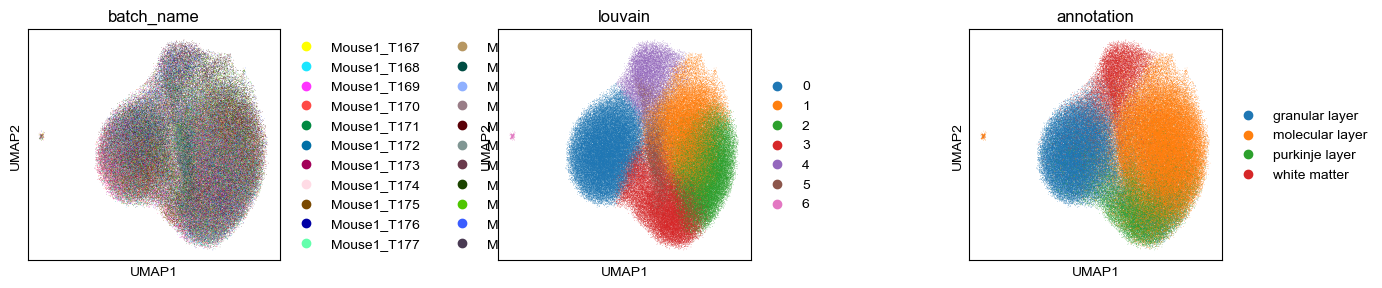

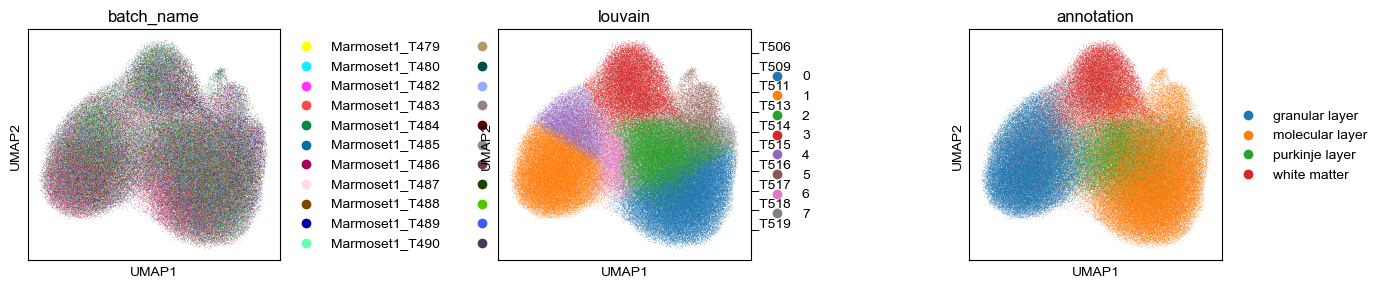

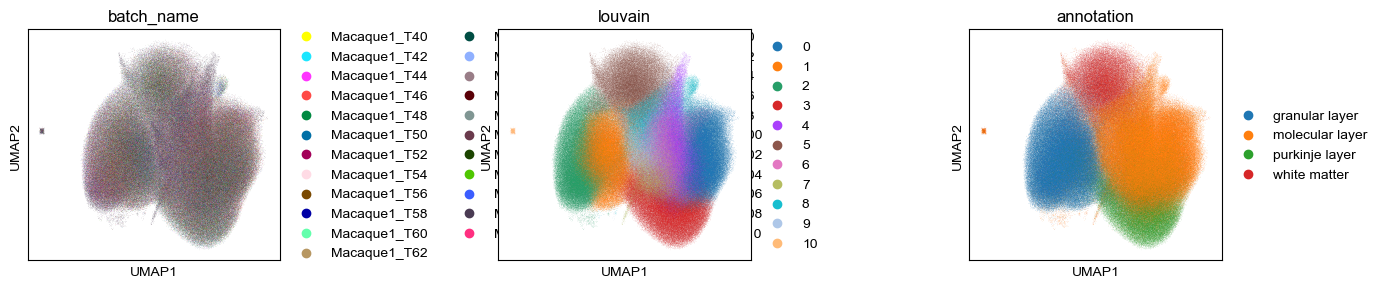

(1174358, 16)


KeyboardInterrupt: 

In [8]:
## %%time
import importlib
from STACAME.train_STACAME import train_STACAME_minibatch, train_STACAME_subgraph
used_device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')

pretrain_device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

for k,v in adata_dict.items():
    print(k, v)

adata_species_dict = train_STACAME_subgraph(adata_dict, 
                           triplet_ind_species_dict = triplet_ind_species_dict, 
                           edge_ndarray_species = edge_ndarray_species, 
                           triplet_ind_sections_dict = triplet_ind_sections_dict, 
                           edge_ndarray_sections = edge_ndarray_sections,
                           hidden_dims=[256, 16], 
                           verbose=True, 
                           key_added = 'STACAME',
                           device=used_device, 
                           stagate_epoch={'Mouse':5, 'Marmoset':5, 'Macaque':5}, 
                           n_epochs_species=5,  #1000
                           margin_species=1,
                           lr=0.001, 
                           lr_species = 0.001,
                           pretrain_device = pretrain_device,
                           mse_beta = 1, 
                           beta = 100,
                           tri_beta = 10, 
                           mmd_beta = 10,
                           mmd_batch_size = 2048, 
                           batch_size = 20000,
                           batch_size_dict = {'Mouse': 50000, 'Marmoset':50000, 'Macaque':50000},
                           if_knn_mnn_graph = False, umap_downsampling_rate = 0.05, if_integrate_within_species = True)



## Save STACAME embeddings

In [ ]:

adata_dict, adata_embedding = combine_adata(adata_species_dict, key_umap='STACAME')

In [ ]:

for species_id, adata in adata_dict.items():
    print(adata.obsm['STACAME'].shape)
    if 'edgeList' in adata.uns.keys():
        del adata.uns['edgeList']
    adata.write(output_path + f'{species_id}.h5ad')
    adata_temp = adata[:, adata.uns['highly_variable']]
    adata_temp.write(output_path + f'adata_{species_id}_expression.h5ad')

from STACAME.analysis import merge_embedding
adata_embedding = merge_embedding(adata_dict, key_umap = 'STACAME')
adata_embedding.obs['region_name'] = adata_embedding.obs['annotation']
adata_embedding.write(output_path + 'adata_embedding.h5ad')





In [ ]:
from sklearn.metrics import adjusted_rand_score as ari_score

import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc

plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 10
fig_format = 'jpg'
fig_dpi = 500
annotation_num = 4

key_umap = 'STACAME'
fig_save_path = output_path


## Do clustering

In [ ]:
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 10
fig_format = 'jpg'
fig_dpi = 500
annotation_num = 4
fig_save_path = output_path
num_clusters =annotation_num
print(f'Mclust {num_clusters} clusters...')
STACAME.mclust_R(adata_embedding, num_cluster=num_clusters, used_obsm='STACAME')

In [ ]:


Batch_list = []

for species_id in species_section_ids.keys():
    adata_temp = adata_embedding[adata_embedding.obs['species_id'].isin([species_id])]
    Batch_list.append(adata_temp)

species_list = list(species_section_ids.keys())
spot_size = 1
title_size = 10
ARI_list = []
for bb in range(3):
    ARI_list.append(round(ari_score(Batch_list[bb].obs['annotation'], Batch_list[bb].obs['mclust']), 2))

fig, ax = plt.subplots(3, 2, figsize=(15, 8), gridspec_kw={'wspace': 0.3, 'hspace': 0.1})

clust_list = list(set(list(Batch_list[0].obs['mclust'].unique()) + list(Batch_list[1].obs['mclust'].unique())))
color_list = sns.color_palette(cc.glasbey, n_colors=len(clust_list))
clust_palette = {k:v for k,v in zip(clust_list, color_list)}
palette = {k:clust_palette[k] for k in Batch_list[0].obs['mclust'].unique()}
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[0][0], frameon=False,
                      spot_size=spot_size, palette=palette)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=title_size)
color_list = sns.color_palette(cc.glasbey, n_colors=len(Batch_list[0].obs['annotation'].unique()))
#palette = {k:v for k,v in zip(Batch_list[0].obs['annotation'].unique(), color_list)}
region_list = ['granular layer', 'molecular layer', 'purkinje layer', 'white matter']
color_list = sns.color_palette(cc.glasbey, n_colors=len(region_list))
palette = {k:v for k,v in zip([x for x in region_list], color_list)}
_sc_1 = sc.pl.spatial(Batch_list[0], img_key=None, color=['annotation'], title=[species_list[0] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[0][1], frameon=False,
                      spot_size=spot_size, palette=palette)
palette = {k:clust_palette[k] for k in Batch_list[1].obs['mclust'].unique()}

spot_size = 1
_sc_2 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[1][0], frameon=False,
                      spot_size=spot_size, palette=palette)
_sc_2[0].set_title("ARI=" + str(ARI_list[1]), size=title_size)
color_list = sns.color_palette(cc.glasbey, n_colors=len(Batch_list[1].obs['annotation'].unique()))
region_list = ['granular layer', 'molecular layer', 'purkinje layer', 'white matter']
color_list = sns.color_palette(cc.glasbey, n_colors=len(region_list))
palette = {k:v for k,v in zip([x for x in region_list], color_list)}
_sc_3 = sc.pl.spatial(Batch_list[1], img_key=None, color=['annotation'], title=[species_list[1] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[1][1], frameon=False, 
                      spot_size=spot_size, palette=palette)


spot_size = 1
_sc_4 = sc.pl.spatial(Batch_list[2], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[2][0], frameon=False,
                      spot_size=spot_size, palette=clust_palette)
_sc_4[0].set_title("ARI=" + str(ARI_list[2]), size=title_size)

_sc_5 = sc.pl.spatial(Batch_list[2], img_key=None, color=['annotation'], title=[species_list[2] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[2][1], frameon=False, 
                      spot_size=spot_size, palette=palette)

if not os.path.exists(fig_save_path):
    os.makedirs(fig_save_path)
plt.savefig(fig_save_path + 'common_mclust.', format=fig_format, dpi=fig_dpi)
plt.show()

## UMAP

In [ ]:
from STACAME.analysis import get_alignment_score, convert_dict2adata
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='white')
TINY_SIZE = 11 # 39
SMALL_SIZE = 11  # 42
MEDIUM_SIZE = 12  # 46
BIGGER_SIZE = 12  # 46

umap_neighbor = 30
umap_size_dict = {'Mouse':1, 'Marmoset':1, 'Macaque':1}
fig_format = 'jpg'

species_color = ['#4778FA', '#8A4AA2', '#ED7A43']
mouse_color = '#0C868E'
marmoset_color = '#8A4AA2'
macaque_color = '#E35234'

save_path = './output_STACAME_subgraph/figs/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

fig_dpi = 400
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labelsc
plt.rc('xtick', labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']


palette = {'Mouse':mouse_color, 'Marmoset':marmoset_color, 'Macaque':macaque_color}

adata_embedding.obs['dataset'] = adata_embedding.obs['species_id']

#sc.tl.pca(adata_embedding, svd_solver='arpack', n_comps=5)
sc.pp.neighbors(adata_embedding, n_neighbors=umap_neighbor, metric='cosine',
                use_rep='X')
sc.tl.umap(adata_embedding)

adata_mouse_embedding = adata_embedding[adata_embedding.obs['dataset'].isin(['Mouse'])]
adata_macaque_embedding = adata_embedding[adata_embedding.obs['dataset'].isin(['Macaque'])]
adata_marmoset_embedding = adata_embedding[adata_embedding.obs['dataset'].isin(['Marmoset'])]

adata_umap_size_list = [umap_size_dict[x] for x in adata_embedding.obs['dataset']]


with plt.rc_context({"figure.figsize": (3, 2.5), "figure.dpi": (fig_dpi)}):
    sc.pl.umap(adata_mouse_embedding, color=['region_name'], return_fig=True, legend_loc='right margin', size=1).savefig(
        save_path + 'umap_mouse.' + fig_format, format=fig_format)


with plt.rc_context({"figure.figsize": (3, 2.5), "figure.dpi": (fig_dpi)}):
    # sc.set_figure_params(dpi_save=200)
    sc.pl.umap(adata_marmoset_embedding, color=['region_name'], return_fig=True, size=1,
               legend_loc='right margin').savefig(
        save_path + 'umap_marmoset.' + fig_format, format=fig_format)


with plt.rc_context({"figure.figsize": (3, 2.5), "figure.dpi": (fig_dpi)}):
    # sc.set_figure_params(dpi_save=200)
    sc.pl.umap(adata_macaque_embedding, color=['region_name'], return_fig=True, size=1,
               legend_loc='right margin').savefig(
        save_path + 'umap_macaque.' + fig_format, format=fig_format)


# plt.subplots_adjust(left=0.1, right=5)
# plt.tight_layout()
rcParams["figure.subplot.left"] = 0.2
rcParams["figure.subplot.right"] = 0.9


rcParams["figure.subplot.left"] = 0.1
rcParams["figure.subplot.right"] = 0.68#0.6545
with plt.rc_context({"figure.figsize": (4, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding, color=['dataset'], return_fig=True, legend_loc='right margin', title='', size= adata_umap_size_list, palette=palette)
    plt.title('')
    fg.savefig(save_path + 'umap_dataset_after_integration_rightmargin.' + fig_format, format=fig_format)


rcParams["figure.subplot.right"] = 0.9
#rcParams["figure.subplot.bottom"] = 0.1
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding, color=['dataset'], return_fig=True, legend_loc=None, title='', size= adata_umap_size_list, palette=palette)
    plt.title('')
    fg.savefig(save_path + 'umap_dataset_after_integration.' + fig_format, format=fig_format)

    

In [ ]:
rcParams["figure.subplot.left"] = 0.1
rcParams["figure.subplot.right"] = 0.68#0.6545
with plt.rc_context({"figure.figsize": (4, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding, color=['slice_name'], return_fig=True, legend_loc='right margin', title='', size= adata_umap_size_list)
    plt.title('')
    fg.savefig(save_path + 'umap_sections_after_integration_rightmargin.' + fig_format, format=fig_format)

In [ ]:
homo_region_file_path = './Data/mouse_marmoset_macaque_homo_region.csv'
labels_dir = './Data/'
path_labels_marmoset = './Data/marmoset_region_list.csv'
path_labels_mouse = './Data/mouse_region_list.csv'
path_labels_macaque = './Data/macaque_region_list.csv'

#    ttest_plot_utils.run_came_homo_random(cfg)

mouse_labels = pd.read_csv(path_labels_mouse)
mouse_labels_list = list(mouse_labels['region_name'])
mouse_acronym_dict = {k: v for k, v in zip(mouse_labels['region_name'], mouse_labels['acronym'])}
mouse_color_dict = {k: v for k, v in
                       zip(mouse_labels['region_name'], mouse_labels['color_hex_triplet'])}
mouse_acronym_color_dict = {k: v for k, v in
                       zip(mouse_labels['acronym'], mouse_labels['color_hex_triplet'])}


marmoset_labels = pd.read_csv(path_labels_marmoset)
marmoset_labels_list = list(marmoset_labels['region_name'])
marmoset_acronym_dict = {k: v for k, v in zip(marmoset_labels['region_name'], marmoset_labels['acronym'])}
marmoset_color_dict = {k: v for k, v in
                       zip(marmoset_labels['region_name'], marmoset_labels['color_hex_triplet'])}
marmoset_acronym_color_dict = {k: v for k, v in
                       zip(marmoset_labels['acronym'], marmoset_labels['color_hex_triplet'])}

macaque_labels = pd.read_csv(path_labels_macaque)
macaque_labels_list = list(macaque_labels['region_name'])
macaque_acronym_dict = {k: v for k, v in zip(macaque_labels['region_name'], macaque_labels['acronym'])}
macaque_color_dict = {k: v for k, v in
                       zip(macaque_labels['region_name'], macaque_labels['color_hex_triplet'])}
macaque_acronym_color_dict = {k: v for k, v in
                       zip(macaque_labels['acronym'], macaque_labels['color_hex_triplet'])}



## Alignment of homologous regions


In [ ]:
rcParams["figure.subplot.left"] = 0.05
rcParams["figure.subplot.right"] = 0.27
rcParams["figure.subplot.bottom"] = 0.15
rcParams["figure.subplot.top"] = 0.9


# if cfg.BrainAlign.homo_region_num >= 10:
mouse_marmoset_human_homo_region = pd.read_csv(homo_region_file_path)

# Here because region name are all the same
homo_region_list = list(mouse_marmoset_human_homo_region['Mouse'].values)


homo_region_color_list = [mouse_color_dict[m_r] for m_r in list(mouse_marmoset_human_homo_region['Mouse'].values)]


adata_mouse_embedding_temp = adata_embedding[adata_embedding.obs['dataset'].isin(['Mouse'])]
adata_marmoset_embedding_temp = adata_embedding[adata_embedding.obs['dataset'].isin(['Marmoset'])]
adata_macaque_embedding_temp = adata_embedding[adata_embedding.obs['dataset'].isin(['Macaque'])]
print(adata_macaque_embedding_temp.obs['region_name'])


adata_embedding_temp = ad.concat([adata_mouse_embedding_temp, 
                                  adata_marmoset_embedding_temp,
                                  adata_macaque_embedding_temp])

homo_region_list_temp = list([x for x in mouse_marmoset_human_homo_region['Mouse'].values])

adata_embedding_homo = adata_embedding[
    adata_embedding.obs['region_name'].isin(homo_region_list)]
adata_embedding_homo_temp = adata_embedding_temp[adata_embedding_temp.obs['region_name'].isin(homo_region_list_temp)]
homo_region_palette = {k:v for k,v in zip(homo_region_list, homo_region_color_list)}
homo_region_palette_temp = {k: v for k, v in zip(homo_region_list_temp, homo_region_color_list)}

rcParams["figure.subplot.left"] = 0.1
rcParams["figure.subplot.right"] = 0.68#0.6545
print(palette)
#print(adata_umap_size_list)
adata_umap_size_list_homo = [umap_size_dict[x] for x in adata_embedding_homo_temp.obs['dataset']]
with plt.rc_context({"figure.figsize": (4, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding_homo_temp, color=['dataset'], return_fig=True,
                    legend_loc='right margin', palette=palette, size=np.array(adata_umap_size_list_homo))
    plt.title('')
    plt.show()
    fg.savefig(save_path + 'umap_homo_species.' + fig_format, format=fig_format)


rcParams["figure.subplot.left"] = 0.1
rcParams["figure.subplot.right"] = 0.35
rcParams["figure.subplot.bottom"] = 0.1
rcParams["figure.subplot.top"] = 0.9

plt.rc('font', size=TINY_SIZE-3)  # 35 controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE-3)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE-1)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=TINY_SIZE-3)  # fontsize of the tick labels
plt.rc('ytick', labelsize=TINY_SIZE-3)  # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE-3)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE-3)  # fontsize of the figure title

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']


with plt.rc_context({"figure.figsize": (10, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding_homo_temp, color=['region_name'], return_fig=True,
                    legend_loc='right margin', palette=homo_region_palette_temp, size=np.array(adata_umap_size_list_homo))
    plt.title('')
    plt.show()
    fg.savefig(
        save_path + 'umap_types.' + fig_format, format=fig_format)

homo_region_color_list_mouse = sns.color_palette(cc.glasbey, n_colors=len(list([x for x in mouse_marmoset_human_homo_region['Mouse'].values])))

homo_region_color_list_mouse = homo_region_color_list_mouse

homo_region_list_temp = list([x for x in mouse_marmoset_human_homo_region['Mouse'].values])

homo_region_palette_mouse = {k: v for k, v in zip(homo_region_list_temp, homo_region_color_list_mouse)}
with plt.rc_context({"figure.figsize": (10, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding_homo_temp, color=['region_name'], return_fig=True,
                    legend_loc='right margin', palette=homo_region_palette_mouse, size=np.array(adata_umap_size_list_homo))
    plt.title('')
    plt.show()
    fg.savefig(
        save_path + 'umap_types_samecolor.' + fig_format, format=fig_format)


## Visualization of Cell types


In [ ]:
cell_type_list = ['Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_stalk', 'Ependymal', 
                  'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Microglia', 
                  'ODC', 'OPC', 'Purkinje', 'UBC']

color_list = ['#EEC7B6', '#E79D8D', '#8ED7E6', '#219EBC', '#CC9A81', 
              '#81B29A', '#A9CBCA',  '#B18D97',  '#FAD678', '#8E9AAF', '#CBC0D3', 
              '#FFB703', '#F7BEEC', '#5965B0', '#E16E6E']

celltype_palette = {k:v for k,v in zip(cell_type_list, color_list)}

fig, ax = plt.subplots(1, len(cell_type_list), figsize=(1.5*len(cell_type_list)+2, 3), gridspec_kw={'wspace': 0, 'hspace': 0.2}, dpi=fig_dpi)

for i in range(len(cell_type_list)):
    cell_type = cell_type_list[i]
    #color_map = 
    _sc_1 = sc.pl.spatial(adata_embedding, img_key=None, color=[cell_type], title=[cell_type], 
                          legend_loc=None, legend_fontsize=10, show=False, ax=ax[i], frameon=False, 
                          spot_size=1,  colorbar_loc=None, palette=celltype_palette) #cell_type
plt.show()

# rcParams["figure.subplot.right"] = 0.9
# #rcParams["figure.subplot.bottom"] = 0.1
# with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (fig_dpi)}):
#     fg = sc.pl.umap(adata_embedding, color=['dataset'], return_fig=True, legend_loc=None, title='', size= adata_umap_size_list, palette=palette)
#     plt.title('')
#     fg.savefig(save_path + 'umap_dataset_after_integration.' + fig_format, format=fig_format)